<a href="https://colab.research.google.com/github/ancestor9/mathematics-for-machine-learning/blob/main/scripts/Linear%20transformation_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

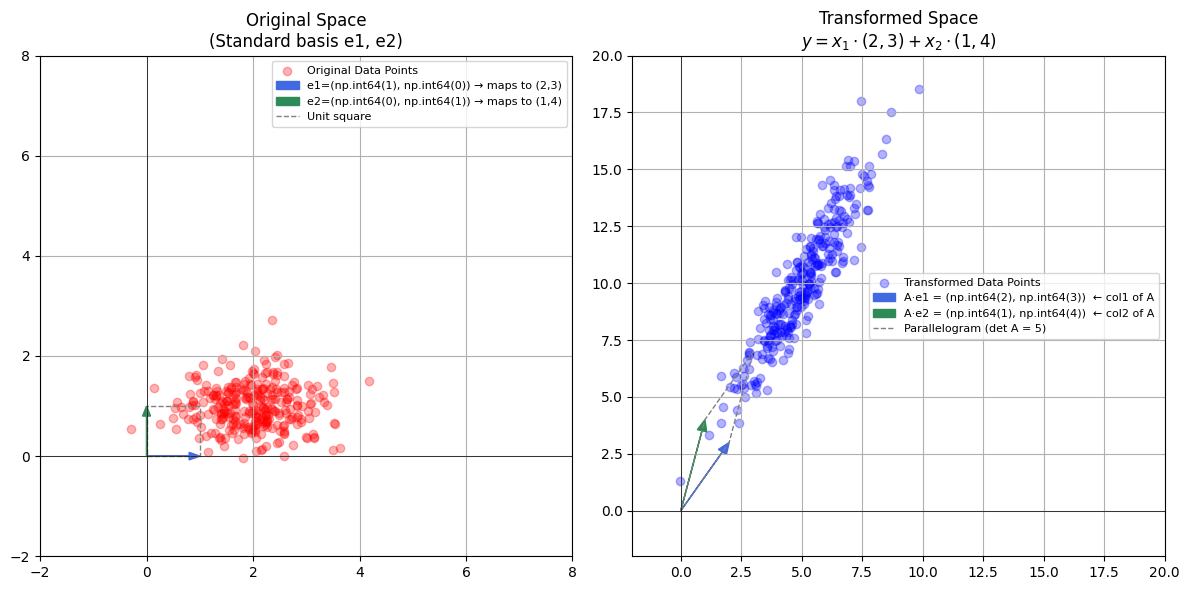

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 생성
np.random.seed(42)
mean = [2, 1]
cov = [[0.5, 0], [0, 0.2]]
data = np.random.multivariate_normal(mean, cov, 300)

# 2. 행렬 변환
# A의 열벡터 col1=(2,3), col2=(1,4)가 새로운 기저
# y = A @ x  ↔  y = x1*(2,3) + x2*(1,4)
A = np.array([[2, 1], [3, 4]])
transformed_data = data @ A.T  # (300,2) @ (2,2) → 올바른 변환

# [수정] 원본 공간의 기저: 표준 기저 e1, e2
# → 이들이 A에 의해 A의 열벡터로 매핑됨을 보여줌
vector1_orig = np.array([1, 0])  # 표준 기저 e1 → A 열1 (2,3)으로 매핑
vector2_orig = np.array([0, 1])  # 표준 기저 e2 → A 열2 (1,4)로 매핑

# [수정] 변환 후 벡터 = A의 열벡터 (A @ e1, A @ e2)
vector1_transformed = A @ vector1_orig  # → (2, 3) : A의 첫 번째 열
vector2_transformed = A @ vector2_orig  # → (1, 4) : A의 두 번째 열

# 3. 시각화
plt.figure(figsize=(12, 6))

# ── 왼쪽: 원본 공간 ──
plt.subplot(1, 2, 1)
plt.scatter(data[:, 0], data[:, 1], alpha=0.3, color='red', label='Original Data Points')

plt.arrow(0, 0, vector1_orig[0], vector1_orig[1],
          head_width=0.15, head_length=0.2, fc='royalblue', ec='royalblue',
          length_includes_head=True, label=f'e1={tuple(vector1_orig)} → maps to (2,3)')
plt.arrow(0, 0, vector2_orig[0], vector2_orig[1],
          head_width=0.15, head_length=0.2, fc='seagreen', ec='seagreen',
          length_includes_head=True, label=f'e2={tuple(vector2_orig)} → maps to (1,4)')

# 단위 정사각형: 변환 전 기저가 이루는 영역
square_x = [0, 1, 1, 0, 0]
square_y = [0, 0, 1, 1, 0]
plt.plot(square_x, square_y, 'gray', linestyle='--', linewidth=1, label='Unit square')

plt.title('Original Space\n(Standard basis e1, e2)')
plt.grid(True)
plt.xlim(-2, 8); plt.ylim(-2, 8)
plt.axhline(0, color='k', lw=0.5); plt.axvline(0, color='k', lw=0.5)
plt.legend(fontsize=8)

# ── 오른쪽: 변환 공간 ──
plt.subplot(1, 2, 2)
plt.scatter(transformed_data[:, 0], transformed_data[:, 1],
            alpha=0.3, color='blue', label='Transformed Data Points')

plt.arrow(0, 0, vector1_transformed[0], vector1_transformed[1],
          head_width=0.4, head_length=0.5, fc='royalblue', ec='royalblue',
          length_includes_head=True,
          label=f'A·e1 = {tuple(vector1_transformed)}  ← col1 of A')
plt.arrow(0, 0, vector2_transformed[0], vector2_transformed[1],
          head_width=0.4, head_length=0.5, fc='seagreen', ec='seagreen',
          length_includes_head=True,
          label=f'A·e2 = {tuple(vector2_transformed)}  ← col2 of A')

# 평행사변형: 단위 정사각형이 변환된 형태
v1 = vector1_transformed
v2 = vector2_transformed
para_x = [0, v1[0], v1[0]+v2[0], v2[0], 0]
para_y = [0, v1[1], v1[1]+v2[1], v2[1], 0]
plt.plot(para_x, para_y, 'gray', linestyle='--', linewidth=1,
         label=f'Parallelogram (det A = {int(np.linalg.det(A))})')

plt.title('Transformed Space\n' +
          r'$y = x_1 \cdot (2,3) + x_2 \cdot (1,4)$')
plt.grid(True)
plt.xlim(-2, 20); plt.ylim(-2, 20)
plt.axhline(0, color='k', lw=0.5); plt.axvline(0, color='k', lw=0.5)
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

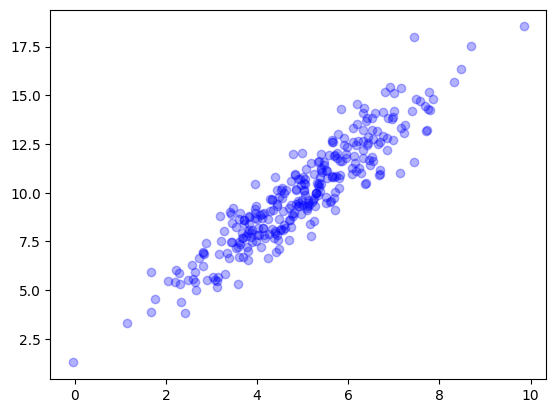

In [ ]:
X = transformed_data
plt.scatter(X[:, 0], X[:, 1], alpha=0.3, color='blue', label='Transformed Data Points')

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(X)

PCA(n_components=2)

In [ ]:
print(pca.components_)

[[ 0.45596615  0.88999712]
 [ 0.88999712 -0.45596615]]


In [ ]:
print(pca.explained_variance_)

[9.28317901 0.24129143]


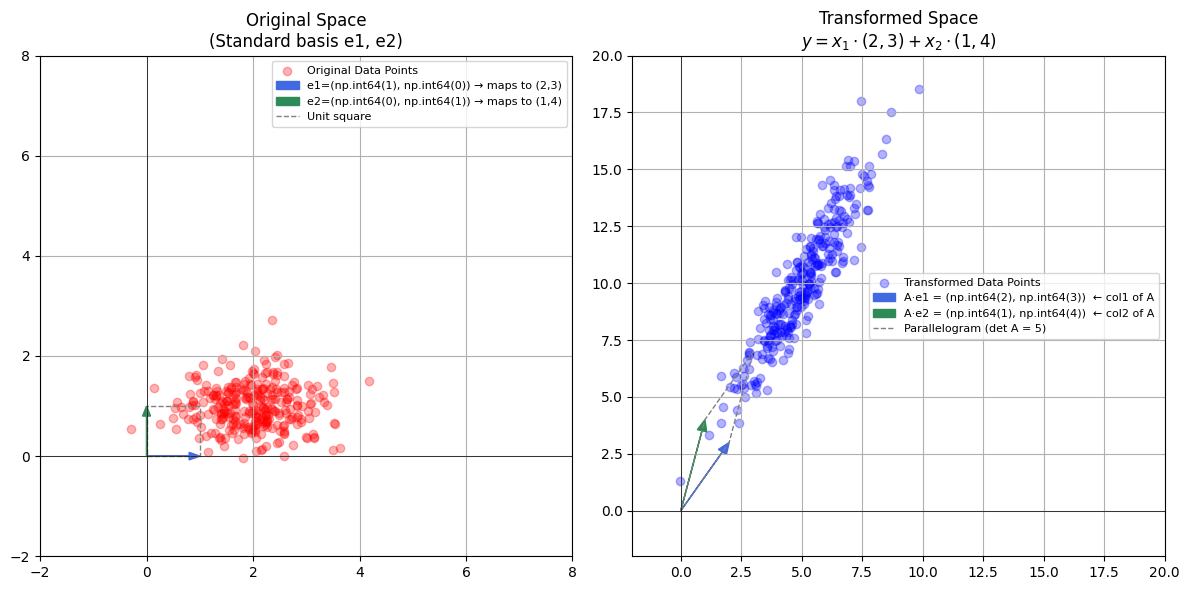

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 생성
np.random.seed(42)
mean = [2, 1]
cov = [[0.5, 0], [0, 0.2]]
data = np.random.multivariate_normal(mean, cov, 300)

# 2. 행렬 변환
# A의 열벡터 col1=(2,3), col2=(1,4)가 새로운 기저
# y = A @ x  ↔  y = x1*(2,3) + x2*(1,4)
A = np.array([[2, 1], [3, 4]])
transformed_data = data @ A.T  # (300,2) @ (2,2) → 올바른 변환

# [수정] 원본 공간의 기저: 표준 기저 e1, e2
# → 이들이 A에 의해 A의 열벡터로 매핑됨을 보여줌
vector1_orig = np.array([1, 0])  # 표준 기저 e1 → A 열1 (2,3)으로 매핑
vector2_orig = np.array([0, 1])  # 표준 기저 e2 → A 열2 (1,4)로 매핑

# [수정] 변환 후 벡터 = A의 열벡터 (A @ e1, A @ e2)
vector1_transformed = A @ vector1_orig  # → (2, 3) : A의 첫 번째 열
vector2_transformed = A @ vector2_orig  # → (1, 4) : A의 두 번째 열

# 3. 시각화
plt.figure(figsize=(12, 6))

# ── 왼쪽: 원본 공간 ──
plt.subplot(1, 2, 1)
plt.scatter(data[:, 0], data[:, 1], alpha=0.3, color='red', label='Original Data Points')

plt.arrow(0, 0, vector1_orig[0], vector1_orig[1],
          head_width=0.15, head_length=0.2, fc='royalblue', ec='royalblue',
          length_includes_head=True, label=f'e1={tuple(vector1_orig)} → maps to (2,3)')
plt.arrow(0, 0, vector2_orig[0], vector2_orig[1],
          head_width=0.15, head_length=0.2, fc='seagreen', ec='seagreen',
          length_includes_head=True, label=f'e2={tuple(vector2_orig)} → maps to (1,4)')

# 단위 정사각형: 변환 전 기저가 이루는 영역
square_x = [0, 1, 1, 0, 0]
square_y = [0, 0, 1, 1, 0]
plt.plot(square_x, square_y, 'gray', linestyle='--', linewidth=1, label='Unit square')

plt.title('Original Space\n(Standard basis e1, e2)')
plt.grid(True)
plt.xlim(-2, 8); plt.ylim(-2, 8)
plt.axhline(0, color='k', lw=0.5); plt.axvline(0, color='k', lw=0.5)
plt.legend(fontsize=8)

# ── 오른쪽: 변환 공간 ──
plt.subplot(1, 2, 2)
plt.scatter(transformed_data[:, 0], transformed_data[:, 1],
            alpha=0.3, color='blue', label='Transformed Data Points')

plt.arrow(0, 0, vector1_transformed[0], vector1_transformed[1],
          head_width=0.4, head_length=0.5, fc='royalblue', ec='royalblue',
          length_includes_head=True,
          label=f'A·e1 = {tuple(vector1_transformed)}  ← col1 of A')
plt.arrow(0, 0, vector2_transformed[0], vector2_transformed[1],
          head_width=0.4, head_length=0.5, fc='seagreen', ec='seagreen',
          length_includes_head=True,
          label=f'A·e2 = {tuple(vector2_transformed)}  ← col2 of A')

# 평행사변형: 단위 정사각형이 변환된 형태
v1 = vector1_transformed
v2 = vector2_transformed
para_x = [0, v1[0], v1[0]+v2[0], v2[0], 0]
para_y = [0, v1[1], v1[1]+v2[1], v2[1], 0]
plt.plot(para_x, para_y, 'gray', linestyle='--', linewidth=1,
         label=f'Parallelogram (det A = {int(np.linalg.det(A))})')

plt.title('Transformed Space\n'
          r'$y = x_1 \cdot (2,3) + x_2 \cdot (1,4)$')
plt.grid(True)
plt.xlim(-2, 20); plt.ylim(-2, 20)
plt.axhline(0, color='k', lw=0.5); plt.axvline(0, color='k', lw=0.5)
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()